## Import common libraries

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import BallTree
from shapely.geometry import Point

In [ ]:
## Load your cleaned data file (.geojson file)

In [2]:

facilities = gpd.read_file("../data/upper_east_facilities.geojson")
print(len(facilities))
facilities.head()

29


,name,amenity,geometry
0,Chansa CHPS,clinic,POINT (-1.19267 10.57269)
1,Gbedembilisi CHPS,clinic,POINT (-1.24661 10.32759)
2,Uwasa CHPS,clinic,POINT (-1.22848 10.48019)
3,Wiesi CHPS,clinic,POINT (-1.33608 10.36876)
4,Duusi CHPS Compound,clinic,POINT (-0.69316 10.77926)


## Extract coordinates

We convert geometry → lat/lon



In [3]:
facilities["lat"] = facilities.geometry.y
facilities["lon"] = facilities.geometry.x

facilities[["lat", "lon"]].head()



,lat,lon
0,10.572686,-1.192668
1,10.327591,-1.246608
2,10.480188,-1.228481
3,10.368756,-1.336077
4,10.779256,-0.693165


## Prepare coordinates for distance calculation



In [ ]:
facility_coords = facilities[["lat", "lon"]].values

# Convert to radians (IMPORTANT)
# Why radians?: Earth is curved. The haversine formula calculates real-world distances on a sphere.
facility_coords_rad = np.radians(facility_coords)

## Build the distance engine

BallTree (fast and accurate for geographic data)

In [5]:
tree = BallTree(facility_coords_rad, metric='haversine')

## Create a grid of locations

Right now you only know where hospitals are.

We need to simulate:

“Where people might be”

So we create a grid over the region.

## Get region boundary

In [6]:
boundary = facilities.geometry.unary_union.convex_hull

C:\Users\USER\AppData\Local\Temp\ipykernel_21220\637506816.py:1: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  boundary = facilities.geometry.unary_union.convex_hull


## Create grid points

This simulates possible locations of people.

In [ ]:
minx, miny, maxx, maxy = boundary.bounds

# adjust step size for speed vs accuracy
step = 0.05  

points = []

x_coords = np.arange(minx, maxx, step)
y_coords = np.arange(miny, maxy, step)

for x in x_coords:
    for y in y_coords:
        point = Point(x, y)
        if boundary.contains(point):
            points.append(point)

print(f"Generated {len(points)} grid points")

Generated 185 grid points


## Convert grid to coordinates

In [10]:
grid_coords = np.array([[p.y, p.x] for p in points])
grid_coords_rad = np.radians(grid_coords)

## Compute distances to nearest facility

In [11]:
distances, _ = tree.query(grid_coords_rad, k=1)

# convert from radians → kilometers
dist_km = distances.flatten() * 6371

## Store results

In [12]:
grid_df = pd.DataFrame({
    "lat": grid_coords[:, 0],
    "lon": grid_coords[:, 1],
    "distance_km": dist_km
})

grid_df.head()

,lat,lon,distance_km
0,10.377591,-1.286077,5.556407
1,10.427591,-1.286077,6.020737
2,10.377591,-1.236077,5.677843
3,10.427591,-1.236077,5.907209
4,10.477591,-1.236077,0.879330


## Quick visualization

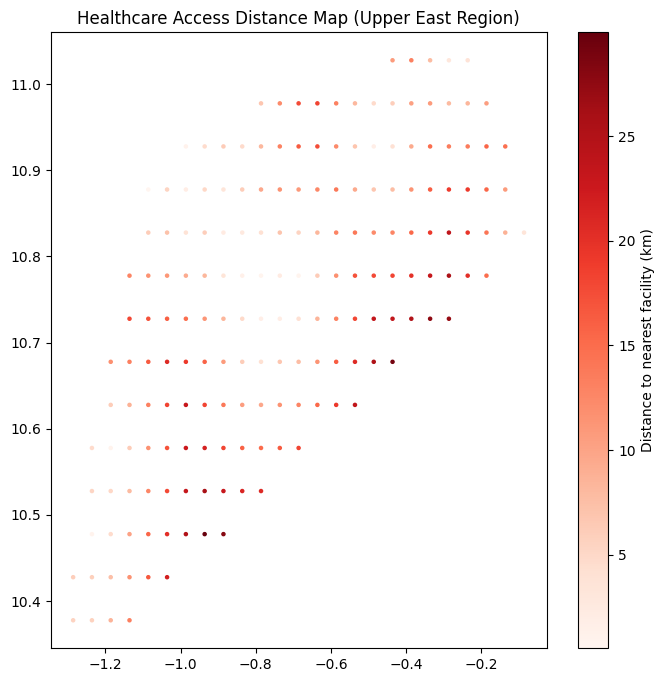

In [13]:
plt.figure(figsize=(8, 8))
plt.scatter(
    grid_df["lon"],
    grid_df["lat"],
    c=grid_df["distance_km"],
    cmap="Reds",
    s=5
)

plt.colorbar(label="Distance to nearest facility (km)")
plt.title("Healthcare Access Distance Map (Upper East Region)")
plt.show()

Distances are calculated as straight-line (Euclidean) approximations using haversine distance, not accounting for road networks

## Save output

In [14]:
grid_df.to_csv("../data/upper_east_distance_grid.csv", index=False)